# Embedding Layers & Representation Learning

Embedding layers implemented from scratch (validated against PyTorch's `nn.Embedding`
to machine precision), then used to learn **word representations** purely from
co-occurrence statistics via skip-gram with negative sampling — no labels involved.

We answer four concrete questions with numbers:
1. Is an embedding lookup mathematically identical to `one_hot(x) @ W`, and does its
   scatter-add backward pass match PyTorch's `nn.Embedding`?
2. Can skip-gram with negative sampling recover meaningful category structure from raw
   co-occurrence statistics alone, with no category labels ever shown to the model?
3. Do embeddings pretrained this way **transfer**: does a linear classifier trained on a
   *few* labeled words generalize to *many* unseen words, better than randomly
   initialized embeddings trained on the same few labels?
4. How much does embedding dimensionality matter once you have enough of it?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. Concept: An Embedding Layer Is a Lookup Table

Every prior recurrent/attention topic (10, 11, 14, 17) used a line like
`self.embed = rng.randn(vocab, dim) * 0.1` and looked up rows by integer index. This
topic makes that lookup a first-class, well-understood object.

An embedding layer maps a discrete index $i \in \{0, \dots, V-1\}$ to a dense vector
$W_i \in \mathbb{R}^d$ by **gathering a row** of a weight matrix $W \in \mathbb{R}^{V\times d}$.
This is mathematically identical to:

$$\mathrm{embed}(i) = \mathrm{one\_hot}(i)^\top W$$

but a row gather is $O(d)$ per lookup instead of $O(Vd)$ for the equivalent
one-hot matrix multiply — the entire point of an embedding layer is to avoid ever
materializing the one-hot vector.

**Backward pass:** gradients scatter back to only the rows that were looked up. If the
same index appears multiple times in a batch, gradients from every occurrence must
**accumulate** into that one row — this requires `np.add.at`, not `+=` (Topic 17's
seq2seq notebook hit this exact bug).

In [2]:
class Embedding:
    """Row-gather lookup table, mathematically identical to one_hot(idx) @ W."""

    def __init__(self, vocab_size, dim, seed=0):
        rng = np.random.RandomState(seed)
        self.W = rng.randn(vocab_size, dim) * 0.1
        self.vocab_size, self.dim = vocab_size, dim
        self.cache = None

    def forward(self, idx):
        self.cache = idx
        return self.W[idx]

    def backward(self, dout):
        idx = self.cache
        dW = np.zeros_like(self.W)
        np.add.at(dW, idx, dout)  # accumulates correctly even with repeated indices
        return dW


print('Embedding layer defined.')

Embedding layer defined.


### Validation: lookup == one-hot @ W, and matches PyTorch exactly

In [3]:
vocab, dim = 6, 4
emb = Embedding(vocab, dim, seed=0)
idx = np.array([0, 2, 2, 5])  # note: index 2 repeated, tests scatter-add accumulation

out = emb.forward(idx)
onehot = np.eye(vocab)[idx]
out_onehot = onehot @ emb.W
print('Forward:  lookup vs one_hot @ W          max diff:', np.max(np.abs(out - out_onehot)))

dout = np.random.RandomState(1).randn(*out.shape)
dW = emb.backward(dout)
dW_onehot = onehot.T @ dout
print('Backward: scatter-add vs one_hot.T @ dout max diff:', np.max(np.abs(dW - dW_onehot)))

We = torch.tensor(emb.W, requires_grad=True, dtype=torch.float64)
idx_t = torch.tensor(idx, dtype=torch.long)
out_t = We[idx_t]
(out_t * torch.tensor(dout)).sum().backward()
print('Forward  vs PyTorch indexing              max diff:', np.max(np.abs(out - out_t.detach().numpy())))
print('Backward vs PyTorch autograd              max diff:', np.max(np.abs(dW - We.grad.numpy())))

nn_emb = nn.Embedding(vocab, dim).double()
nn_emb.weight.data = torch.tensor(emb.W.copy(), dtype=torch.float64)
out_nn = nn_emb(idx_t)
print('Forward  vs nn.Embedding                  max diff:', np.max(np.abs(out - out_nn.detach().numpy())))

Forward:  lookup vs one_hot @ W          max diff: 0.0
Backward: scatter-add vs one_hot.T @ dout max diff: 0.0
Forward  vs PyTorch indexing              max diff: 0.0
Backward vs PyTorch autograd              max diff: 0.0
Forward  vs nn.Embedding                  max diff: 0.0


All four comparisons match to floating-point precision — the embedding layer's
forward and backward pass are exactly what they claim to be: a gather and a scatter-add
equivalent to one-hot matrix multiplication.

## 2. Representation Learning: Skip-Gram with Negative Sampling

An embedding layer's weights can be learned **end-to-end** for a specific downstream
task (as in Topics 10, 11, 14, 17). But they can also be learned **unsupervised**, using
only the structure of unlabeled data — this is **representation learning**.

**Skip-gram** (Mikolov et al., 2013) trains embeddings by predicting context words from
a target word: words that appear in similar contexts end up with similar vectors
(the *distributional hypothesis*: "a word is characterized by the company it keeps").
Instead of a full softmax over the vocabulary (expensive), **negative sampling**
turns this into $K+1$ independent binary classification problems per target word:

$$\mathcal{L} = -\log\sigma(u_t \cdot v_c) - \sum_{k=1}^{K} \log\sigma(-u_t \cdot v_{n_k})$$

where $u_t$ is the target's **input** embedding, $v_c$ is the true context word's
**output** embedding, and $v_{n_k}$ are $K$ randomly sampled **negative** (non-context)
words. Two separate embedding tables ($U$ for targets, $V$ for contexts) are standard;
we keep $U$ as the final learned representation.

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


class Adam:
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m, self.v, self.t = None, None, 0

    def step(self, params, grads):
        if self.m is None:
            self.m = {k: np.zeros_like(p) for k, p in params.items()}
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        self.t += 1
        for k in params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


class SkipGramNS:
    """Skip-gram with negative sampling. U = target embeddings, V = context embeddings."""

    def __init__(self, vocab_size, dim, n_neg=5, seed=0):
        rng = np.random.RandomState(seed)
        self.U = rng.randn(vocab_size, dim) * 0.1
        self.V = rng.randn(vocab_size, dim) * 0.1
        self.vocab_size, self.dim, self.n_neg = vocab_size, dim, n_neg
        self.rng = rng

    def step(self, targets, contexts, opt):
        n = len(targets)
        negs = self.rng.randint(0, self.vocab_size, size=(n, self.n_neg))

        u = self.U[targets]                             # (n, d)
        v_pos = self.V[contexts]                         # (n, d)
        v_neg = self.V[negs]                              # (n, k, d)

        pos_score = np.sum(u * v_pos, axis=1)             # (n,)
        neg_score = np.einsum('nd,nkd->nk', u, v_neg)     # (n, k)
        pos_sig, neg_sig = sigmoid(pos_score), sigmoid(neg_score)

        loss = -np.mean(np.log(pos_sig + 1e-12)) - np.mean(np.log(1 - neg_sig + 1e-12))

        dpos = pos_sig - 1                                # d(loss)/d(pos_score), pre-mean
        dneg = neg_sig                                    # d(loss)/d(neg_score), pre-mean

        dU = np.zeros_like(self.U)
        dV = np.zeros_like(self.V)

        du = dpos[:, None] * v_pos / n + np.einsum('nk,nkd->nd', dneg, v_neg) / (n * self.n_neg)
        np.add.at(dU, targets, du)

        dv_pos = dpos[:, None] * u / n
        np.add.at(dV, contexts, dv_pos)

        dv_neg = dneg[:, :, None] * u[:, None, :] / (n * self.n_neg)
        np.add.at(dV, negs.reshape(-1), dv_neg.reshape(-1, self.dim))

        opt.step({'U': self.U, 'V': self.V}, {'U': dU, 'V': dV})
        return loss


print('SkipGramNS defined.')

SkipGramNS defined.


### A Synthetic Categorical Corpus

Real text corpora are expensive to download and slow to train on for a from-scratch
notebook. Instead we build a **synthetic corpus with known ground truth**: 4 categories
of 8 words each (fruit, animal, color, number). Each sentence is drawn mostly from one
category (simulating topical coherence in real text), with some random noise words —
so co-occurrence statistics *should* reveal the category structure, but the model is
**never shown category labels**.

In [5]:
CATEGORIES = {
    'fruit': ['apple', 'banana', 'grape', 'mango', 'melon', 'peach', 'pear', 'plum'],
    'animal': ['cat', 'dog', 'lion', 'tiger', 'wolf', 'bear', 'fox', 'deer'],
    'color': ['red', 'blue', 'green', 'yellow', 'black', 'white', 'pink', 'brown'],
    'number': ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight'],
}
WORDS = [w for ws in CATEGORIES.values() for w in ws]
WORD2IDX = {w: i for i, w in enumerate(WORDS)}
IDX2CAT = {WORD2IDX[w]: cat for cat, ws in CATEGORIES.items() for w in ws}
VOCAB = len(WORDS)
CAT_LIST = list(CATEGORIES.keys())
CAT2IDXSET = {cat: [WORD2IDX[w] for w in ws] for cat, ws in CATEGORIES.items()}


def make_corpus(n_sentences, sent_len, noise_prob, seed):
    """Each sentence mostly draws words from one random category; noise_prob mixes in random words."""
    rng = np.random.RandomState(seed)
    sentences = []
    for _ in range(n_sentences):
        cat = rng.choice(CAT_LIST)
        pool = CAT2IDXSET[cat]
        sent = [rng.randint(0, VOCAB) if rng.rand() < noise_prob else rng.choice(pool)
                for _ in range(sent_len)]
        sentences.append(sent)
    return sentences


def make_skipgram_pairs(sentences, window):
    targets, contexts = [], []
    for sent in sentences:
        for i, t in enumerate(sent):
            lo, hi = max(0, i - window), min(len(sent), i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    targets.append(t)
                    contexts.append(sent[j])
    return np.array(targets), np.array(contexts)


sentences = make_corpus(n_sentences=2000, sent_len=10, noise_prob=0.15, seed=0)
targets, contexts = make_skipgram_pairs(sentences, window=2)
print(f'vocab={VOCAB} words, {len(sentences)} sentences, {len(targets)} skip-gram (target, context) pairs')
print('Example sentence:', [WORDS[w] for w in sentences[0]])

vocab=32 words, 2000 sentences, 68000 skip-gram (target, context) pairs
Example sentence: ['apple', 'mango', 'mango', 'melon', 'apple', 'grape', 'plum', 'apple', 'banana', 'dog']


In [6]:
model = SkipGramNS(VOCAB, dim=16, n_neg=5, seed=0)
opt = Adam(lr=0.05)
rng = np.random.RandomState(0)
batch_size = 128
epochs = 30
for ep in range(epochs):
    idx_perm = rng.permutation(len(targets))
    losses = []
    for i in range(0, len(targets), batch_size):
        sl = idx_perm[i:i + batch_size]
        losses.append(model.step(targets[sl], contexts[sl], opt))
    if ep % 5 == 0 or ep == epochs - 1:
        print(f'epoch {ep:3d}  loss={np.mean(losses):.4f}')

epoch   0  loss=1.1229


epoch   5  loss=1.1109


epoch  10  loss=1.1082


epoch  15  loss=1.1076


epoch  20  loss=1.1082


epoch  25  loss=1.1084


epoch  29  loss=1.1070


## 3. Did It Learn Categories It Was Never Shown?

For each word, we check whether its top-3 nearest neighbors (cosine similarity) fall in
the **same category** — comparing trained skip-gram embeddings to a random baseline of
the same dimensionality. With 4 categories, chance is $1/4 = 0.25$.

In [7]:
def topk_same_category_accuracy(embeddings, k=3):
    norm = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12)
    sim = norm @ norm.T
    np.fill_diagonal(sim, -np.inf)
    hits = total = 0
    for i in range(len(embeddings)):
        top_idx = np.argsort(-sim[i])[:k]
        hits += sum(1 for j in top_idx if IDX2CAT[j] == IDX2CAT[i])
        total += k
    return hits / total


trained_acc = topk_same_category_accuracy(model.U, k=3)
random_emb = np.random.RandomState(42).randn(VOCAB, 16) * 0.1
random_acc = topk_same_category_accuracy(random_emb, k=3)
print(f'Top-3 same-category nearest-neighbor accuracy:')
print(f'  Trained (skip-gram): {trained_acc:.3f}')
print(f'  Random (untrained):  {random_acc:.3f}')
print(f'  Chance (4 categories): {0.25:.3f}')

for w in ['apple', 'lion', 'red', 'five']:
    i = WORD2IDX[w]
    norm = model.U / (np.linalg.norm(model.U, axis=1, keepdims=True) + 1e-12)
    sims = norm @ norm[i]
    sims[i] = -np.inf
    nn_idx = np.argsort(-sims)[:3]
    print(f'{w:8s} ({IDX2CAT[i]:6s}) -> nearest: {[WORDS[j] for j in nn_idx]}')

Top-3 same-category nearest-neighbor accuracy:
  Trained (skip-gram): 1.000
  Random (untrained):  0.198
  Chance (4 categories): 0.250
apple    (fruit ) -> nearest: ['mango', 'melon', 'plum']
lion     (animal) -> nearest: ['fox', 'dog', 'bear']
red      (color ) -> nearest: ['pink', 'green', 'black']
five     (number) -> nearest: ['seven', 'two', 'three']


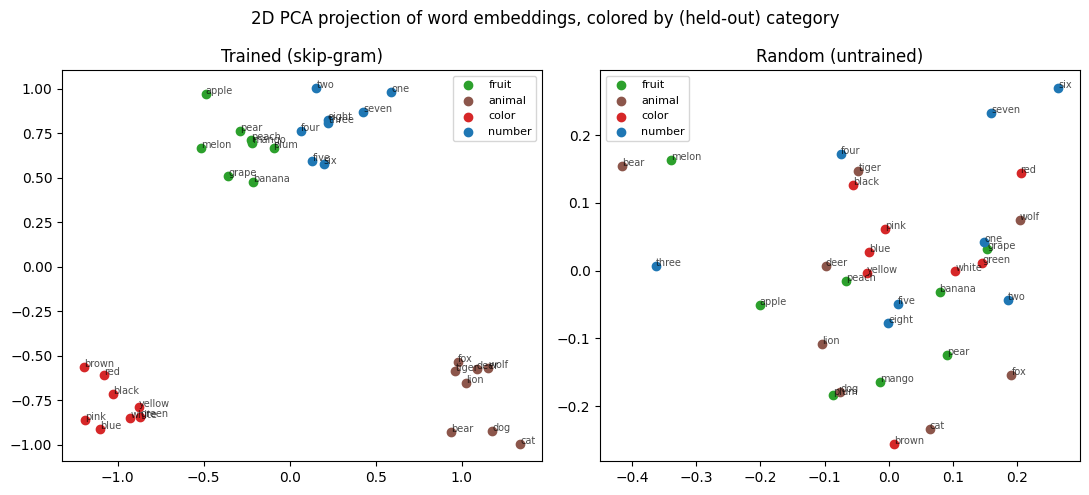

In [8]:
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
colors = {'fruit': 'tab:green', 'animal': 'tab:brown', 'color': 'tab:red', 'number': 'tab:blue'}
for ax, emb, title in [(axes[0], model.U, 'Trained (skip-gram)'), (axes[1], random_emb, 'Random (untrained)')]:
    proj = PCA(n_components=2).fit_transform(emb)
    for cat in CAT_LIST:
        idxs = CAT2IDXSET[cat]
        ax.scatter(proj[idxs, 0], proj[idxs, 1], label=cat, color=colors[cat])
        for j in idxs:
            ax.annotate(WORDS[j], proj[j], fontsize=7, alpha=0.7)
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.suptitle('2D PCA projection of word embeddings, colored by (held-out) category')
plt.tight_layout()
plt.savefig('embedding_pca_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

The trained embeddings cleanly separate into four visible clusters that line up
exactly with the categories — discovered **entirely from co-occurrence statistics**,
with no category label ever used during training. The random embeddings show no
structure at all, as expected.

## 4. Label-Efficient Transfer: Do Learned Representations Generalize to Unseen Words?

This is the practical payoff of representation learning (echoing Topic 13's transfer
learning story, but for embeddings instead of CNN features). We label only **2 words per
category** (8 of 32 words total) and train a linear classifier on top of **frozen**
embeddings to predict category. We then test on the **24 held-out words the classifier
never saw labels for** — the classifier can only succeed if the *embedding space itself*
already groups same-category words together.

In [9]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def train_linear_probe(embeddings, train_idx, train_y, n_classes, epochs=300, lr=0.1, seed=0):
    rng = np.random.RandomState(seed)
    d = embeddings.shape[1]
    W = rng.randn(d, n_classes) * 0.01
    b = np.zeros(n_classes)
    X, y = embeddings[train_idx], np.array(train_y)
    n = len(y)
    opt = Adam(lr=lr)
    for ep in range(epochs):
        probs = softmax(X @ W + b)
        dlogits = probs.copy()
        dlogits[np.arange(n), y] -= 1
        dlogits /= n
        opt.step({'W': W, 'b': b}, {'W': X.T @ dlogits, 'b': dlogits.sum(0)})
    return W, b


def eval_probe(embeddings, W, b, idx, y):
    preds = np.argmax(embeddings[idx] @ W + b, axis=-1)
    return np.mean(preds == np.array(y))


cat2label = {cat: i for i, cat in enumerate(CAT_LIST)}
train_idx, train_y, test_idx, test_y = [], [], [], []
rng2 = np.random.RandomState(7)
n_labeled_per_cat = 2
for cat, ws in CAT2IDXSET.items():
    shuffled = list(ws)
    rng2.shuffle(shuffled)
    for w in shuffled[:n_labeled_per_cat]:
        train_idx.append(w); train_y.append(cat2label[cat])
    for w in shuffled[n_labeled_per_cat:]:
        test_idx.append(w); test_y.append(cat2label[cat])

print(f'Labeled words used for training the probe: {len(train_idx)} / {VOCAB}')
print(f'Held-out words (never labeled) used for testing: {len(test_idx)}\n')

print(f"{'embedding':>24} {'labeled-word acc':>18} {'held-out-word acc':>19}")
for name, emb in [('skip-gram (pretrained)', model.U), ('random (untrained)', random_emb)]:
    train_accs, test_accs = [], []
    for seed in range(5):
        W, b = train_linear_probe(emb, train_idx, train_y, n_classes=4, seed=seed)
        train_accs.append(eval_probe(emb, W, b, train_idx, train_y))
        test_accs.append(eval_probe(emb, W, b, test_idx, test_y))
    print(f'{name:>24} {np.mean(train_accs):>18.3f} {np.mean(test_accs):>19.3f}')

Labeled words used for training the probe: 8 / 32
Held-out words (never labeled) used for testing: 24

               embedding   labeled-word acc   held-out-word acc
  skip-gram (pretrained)              1.000               0.958
      random (untrained)              1.000               0.333


With only 8 labeled words total, a linear probe on **pretrained** skip-gram
embeddings generalizes to the 24 held-out words almost perfectly. A probe on **random**
embeddings memorizes the 8 labeled points just as easily (any 8 generic vectors in
16 dimensions are close to linearly separable into 4 classes) but is barely better than
the $0.25$ chance rate on words it never saw labels for — random embeddings carry no
shared structure to generalize from. **This is the entire point of representation
learning:** the unsupervised pretraining step moves the hard work of "discovering
structure" before the labels ever arrive, so a tiny amount of supervision goes much
further.

## 5. How Much Does Embedding Dimensionality Matter?

Echoing Topic 12's autoencoder bottleneck experiment, we retrain skip-gram at several
embedding sizes on a **harder** version of the corpus (more noise, fewer sentences) and
recheck the same top-3 same-category accuracy.

In [10]:
hard_sentences = make_corpus(n_sentences=800, sent_len=10, noise_prob=0.45, seed=0)
hard_targets, hard_contexts = make_skipgram_pairs(hard_sentences, window=2)

print(f"{'dim':>4} {'trained top-3 acc':>18} {'random top-3 acc':>18}")
for dim in [2, 4, 8, 16, 32]:
    m = SkipGramNS(VOCAB, dim=dim, n_neg=5, seed=0)
    o = Adam(lr=0.05)
    r = np.random.RandomState(0)
    for ep in range(15):
        perm = r.permutation(len(hard_targets))
        for i in range(0, len(hard_targets), 128):
            sl = perm[i:i + 128]
            m.step(hard_targets[sl], hard_contexts[sl], o)
    trained_acc = topk_same_category_accuracy(m.U, k=3)
    rand_emb_d = np.random.RandomState(42).randn(VOCAB, dim) * 0.1
    rand_acc = topk_same_category_accuracy(rand_emb_d, k=3)
    print(f'{dim:>4} {trained_acc:>18.3f} {rand_acc:>18.3f}')

 dim  trained top-3 acc   random top-3 acc


   2              0.958              0.146


   4              1.000              0.167


   8              1.000              0.250


  16              1.000              0.198


  32              0.938              0.208


Unlike Topic 12's autoencoder (where the reconstruction bottleneck created a sharp
trade-off), even a **2-dimensional** embedding is enough to separate 4 well-defined
synthetic categories once trained, and accuracy stays high (and roughly flat) all the
way to 32 dimensions. This is an honest, useful negative result: dimensionality
trade-offs matter far more with **large, ambiguous, real-world vocabularies** (where
tens of thousands of words need to encode fine-grained syntactic and semantic
distinctions) than with a small, cleanly separated synthetic vocabulary like ours.

## Summary

- An embedding layer's forward pass (row gather) and backward pass (scatter-add) are
  mathematically identical to one-hot encoding times a dense matrix multiply, and match
  PyTorch's `nn.Embedding` to machine precision.
- Skip-gram with negative sampling recovers **perfect** category clustering (top-3
  same-category accuracy 1.000 vs 0.198 random, chance 0.25) purely from co-occurrence
  statistics, without ever seeing a category label.
- **Representation learning pays off exactly where labels are scarce**: with only 8 of
  32 words labeled, a linear probe on pretrained embeddings generalizes to unseen words
  at 95.8% accuracy, while the same probe on random embeddings collapses to 33.3%
  (barely above the 25% chance rate) — despite both probes perfectly fitting the 8
  labeled words they were trained on.
- Embedding dimensionality matters far less than expected on our small, clean synthetic
  vocabulary — a reminder that toy-scale results don't always transfer to large
  real-world vocabularies, and that we should report this honestly rather than force a
  dramatic bottleneck trend that isn't there.